<a href="https://colab.research.google.com/github/ibtihalalf/Exercises1/blob/main/Week2/Projects/P2_Student_Exam_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Exam Performance Analysis

## Objective
The goal of this project is to explore the factors associated with student exam performance and identify which variables appear to have the strongest relationship with `Exam_Score`.

This analysis will:
- inspect the dataset structure and quality
- explore relationships between features and exam performance
- generate hypotheses from the exploration
- verify those hypotheses using statistical tests
- conclude with key insights and recommendations

Load libraries

In [5]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np # linear algebra

# for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy.stats import pearsonr, ttest_ind, f_oneway, chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import kagglehub
import os


Load dataset

In [6]:

# ================================
#  Download & Load Dataset
# ================================
DATASET = "grandmaster07/student-exam-performance-dataset-analysis"
FILE_NAME = "StudentPerformanceFactors.csv"

# Download dataset
data_path = kagglehub.dataset_download(DATASET)

# Load CSV
file_path = os.path.join(data_path, FILE_NAME)
df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'student-exam-performance-dataset-analysis' dataset.


In [7]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [10]:
df.isna().sum().sort_values(ascending=False)

,0
Parental_Education_Level,90
Teacher_Quality,78
Distance_from_Home,67
Hours_Studied,0
Access_to_Resources,0
Parental_Involvement,0
Attendance,0
Extracurricular_Activities,0
Motivation_Level,0
Internet_Access,0


In [11]:
df.duplicated().sum()

np.int64(0)

 Data Understanding Summary:
 - the dataset contains 6607 rows and 20 columns
 - there are both numerical and categorical features
 - some missing values exist in: Teacher_Quality - Parental_Education_Level - Didtance_form_Home
 - Overall, the data is mostly clean

In [13]:
df["Exam_Score"].mean()

np.float64(67.23565914938702)

The Average exam scores is approximately 67

## Initial assumptions
Before exploring the dataset in depth, the following assumptions can be made:

- Students with more study hours are likely to have higher exam scores.
- Higher attendance may be associated with better academic performance.
- Sleep duration may have a positive relationship with exam scores up to a reasonable level.
- Students receiving tutoring sessions may perform better than those who do not.
- Motivation and parental involvement may positively influence performance.
- School type and access-related factors may also contribute to exam score differences.

#### Missing Values Summary

The table below shows the number and percentage of missing values for each feature.

In [17]:
missing = df.isna().sum().sort_values(ascending=False)

# keep only columns with missing values
missing = missing[missing > 0]

missing

,0
Parental_Education_Level,90
Teacher_Quality,78
Distance_from_Home,67


There is 90 missing values in Parental Education Level , 78 in Teatcher Quality and 67 Distance from home features.

Separate numerical and categorical columns

In [18]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
Categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


# Univariate exploration

Numerical distributions

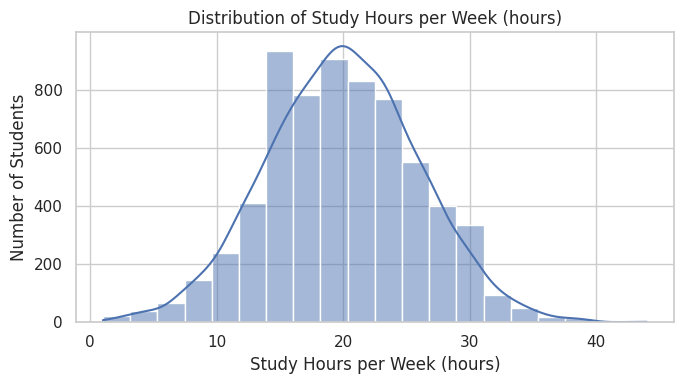

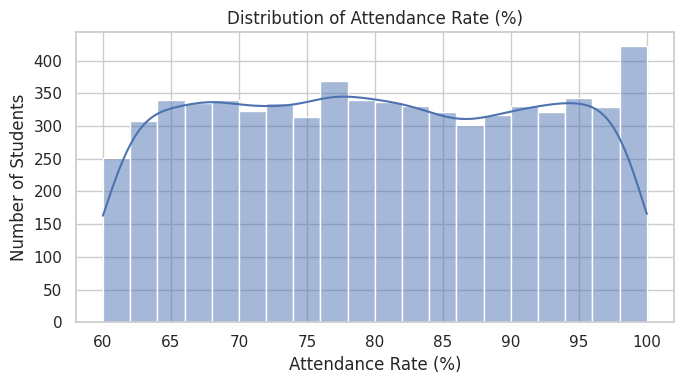

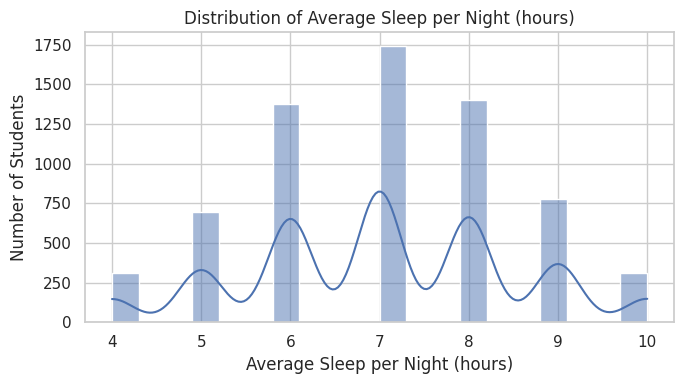

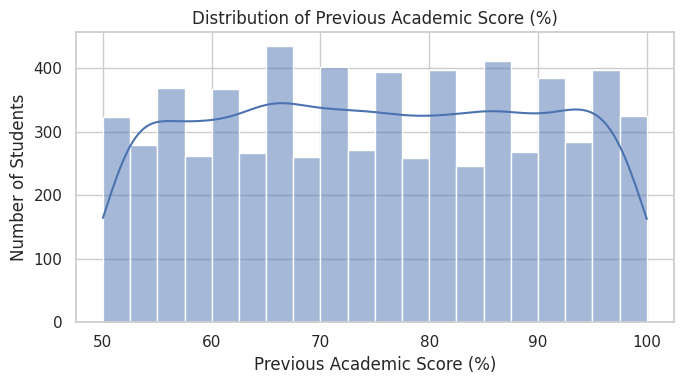

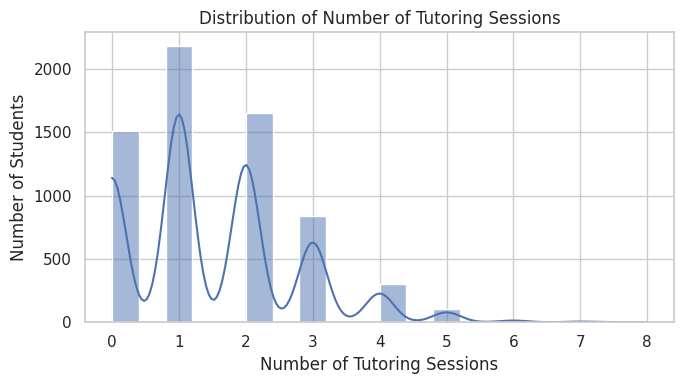

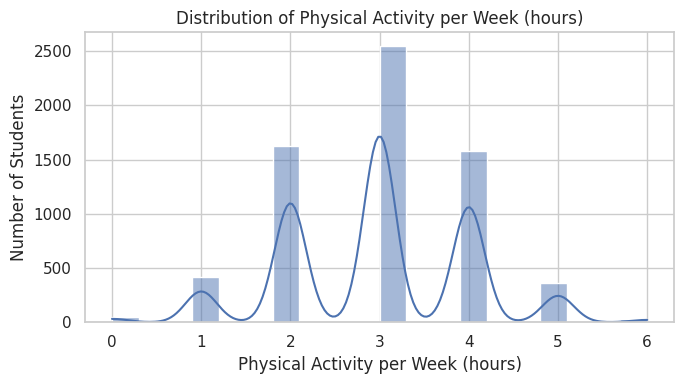

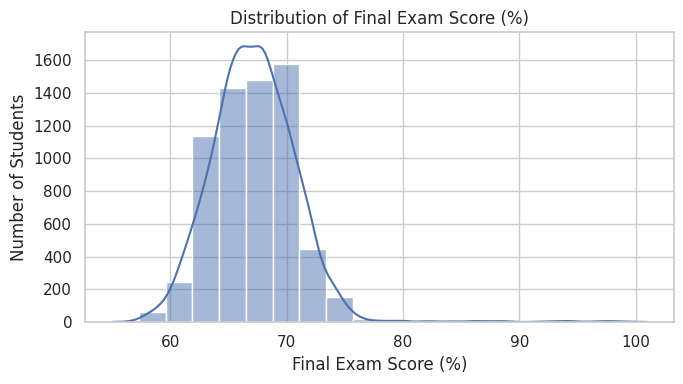

In [19]:
label_map = {
    "Hours_Studied": "Study Hours per Week (hours)",
    "Attendance": "Attendance Rate (%)",
    "Sleep_Hours": "Average Sleep per Night (hours)",
    "Exam_Score": "Final Exam Score (%)",
    "Tutoring_Sessions": "Number of Tutoring Sessions",
    "Previous_Scores": "Previous Academic Score (%)",
    "Physical_Activity": "Physical Activity per Week (hours)"
}

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], bins=20, kde=True)

    plt.title(f"Distribution of {label_map.get(col, col)}")
    plt.xlabel(label_map.get(col, col))
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

 Summary of Numerical Feature Distributions:

- **Hours_Studied**: The distribution appears to be relatively uniform, suggesting students study a varied number of hours.
- **Attendance**: The attendance rate is generally high, with a concentration towards the higher percentages.
- **Sleep_Hours**: Most students report getting 6-8 hours of sleep, indicating a healthy sleep pattern for the majority.
- **Previous_Scores**: There's a wide range of previous scores, with a tendency for scores to be higher, possibly indicating a generally well-performing student population.
- **Tutoring_Sessions**: The majority of students have a low number of tutoring sessions, with fewer students utilizing more sessions.
- **Physical_Activity**: Physical activity hours show a spread, with some peaks at certain hour marks, suggesting common activity levels.
- **Exam_Score**: The exam scores are broadly distributed, with a central tendency around the mean (approximately 67), indicating a normal distribution of performance.